In [1]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch
from utils import *

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
triplets_original = [train_original[i]['triplets'] for i in range(len(train_original))]

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


# VAE posterior sampling given an input

In [7]:
from utils import load_model, get_pred_and_gt, verb_accuracy, handle_verbs_out, to_triplets

# VAE 1: separate=False, eps=0.1
model_path_vae = 'experiments/best_VAE1000_sep=True_od=256_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_eps=0.1_1719244127/checkpoints/last.ckpt'
vae = load_model('vae', model_path_vae, separate=True)
verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)

Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


In [3]:
verbs_predictions_vae = handle_verbs_out(verbs_output_vae)
print(f"{(verb_accuracy(verbs_predictions_vae, verbs_gt_vae)):.3f} %")
gt_vae, pred_vae = to_triplets(verbs_gt_vae, rels_gt_vae, verbs_output_vae, rels_output_vae)

99.843 %


In [4]:
# triplets that should be present but instead are predicted empty
count=0 
for el in pred_vae:
    if el.numel()==0:
        count+=1
print(f"{(count*100/len(pred_vae)):.3f} %")

0.026 %


In [5]:
correct_vae = 0
error_indices_vae = []
for i in range(len(gt_vae)):
    if gt_vae[i].size(0) == pred_vae[i].size(0):
        if torch.all((gt_vae[i] == pred_vae[i])):
            correct_vae += 1
    else:
        error_indices_vae.append(i)
print(f"{(correct_vae*100/len(gt_vae)):.2f} %")

89.04 %


# Prior Sampling (From a Random Latent Space Vector)

In [22]:
num_samples = 3822
codes_dim = 256

decoder = vae.decoder.to(device)
decoded_samples = decoder(torch.randn(num_samples, codes_dim).to(device))
decoded_triplets = get_pred_triplets(decoded_samples[0], decoded_samples[1])

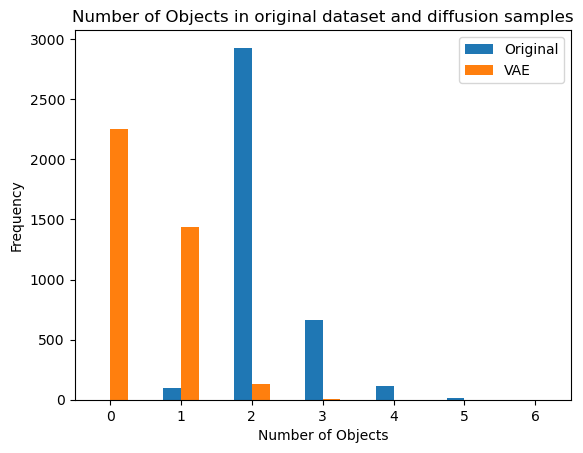

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the number of objects in each training and validation sample
num_objects_train = [triplets_original[i].size(0) for i in range(len(triplets_original))]
num_objects_diff = [decoded_triplets[i].size(0) for i in range(len(decoded_triplets))]

# Convert to pandas Series
objects_train_pd = pd.Series(num_objects_train, name='Train')
objects_diff_pd = pd.Series(num_objects_diff, name='Validation')

# Get value counts and sort by index
objects_train_count = objects_train_pd.value_counts().sort_index()
objects_diff_count = objects_diff_pd.value_counts().sort_index()

# Combine both Series into a DataFrame
objects_count_df = pd.DataFrame({'Original': objects_train_count, 'VAE': objects_diff_count}).fillna(0)

objects_count_df.plot.bar()
plt.xticks(rotation=0)
plt.title('Number of Objects in original dataset and diffusion samples')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()


In [25]:
# Initialize counters
count_0 = 0
count_1 = 0
count_2 = 0
count_3 = 0

# Loop through triplets_diffusion once
for el in decoded_triplets:
    triplet_size = el.size(0)
    if triplet_size == 0:
        count_0 += 1
    elif triplet_size == 1:
        count_1 += 1
    elif triplet_size == 2:
        count_2 += 1
    elif triplet_size == 3:
        count_3 += 1

# Total number of elements
total = len(decoded_triplets)

# Print the percentages
print(f'{(count_0 * 100 / total):.2f} % of graphs result in empty triplets')
print(f'{(count_1 * 100 / total):.2f} % of graphs have 1 triplet')
print(f'{(count_2 * 100 / total):.2f} % of graphs have 2 triplets')
print(f'{(count_3 * 100 / total):.2f} % of graphs have 3 triplets')

58.87 % of graphs result in empty triplets
37.68 % of graphs have 1 triplet
3.32 % of graphs have 2 triplets
0.13 % of graphs have 3 triplets


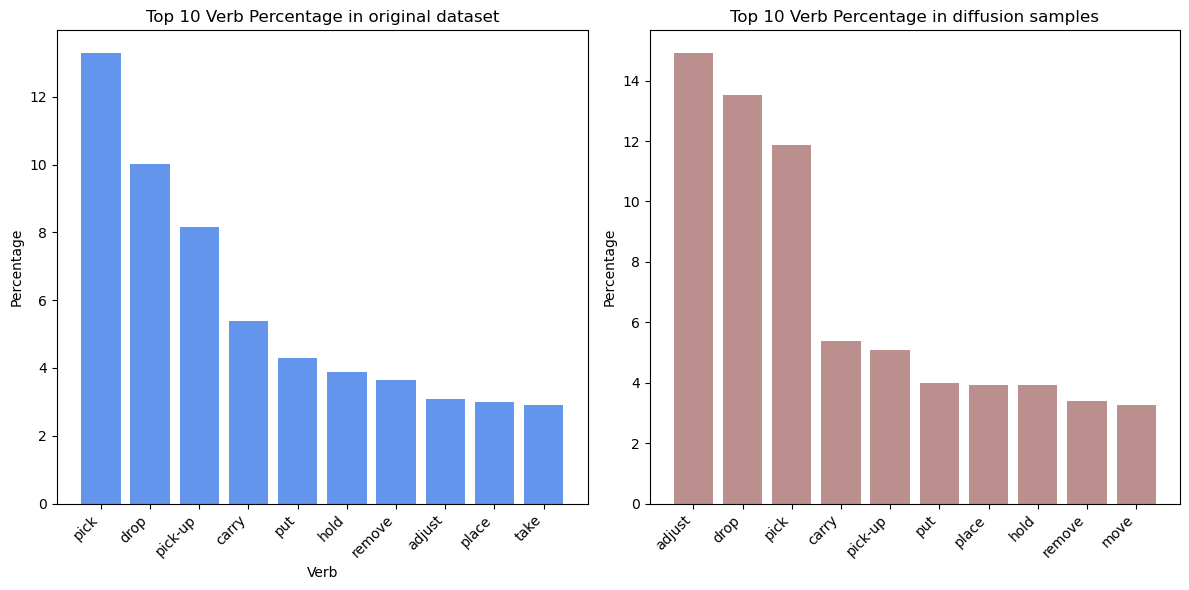

In [26]:
from utils import compare_statistics
verbs_list_original = [triplet[0].item() for triplets in triplets_original for triplet in triplets]
verbs_list_vae = [triplet[0].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics(verbs_list_original, verbs_list_vae, verbs, 'original dataset', 'diffusion samples', 'Verb')

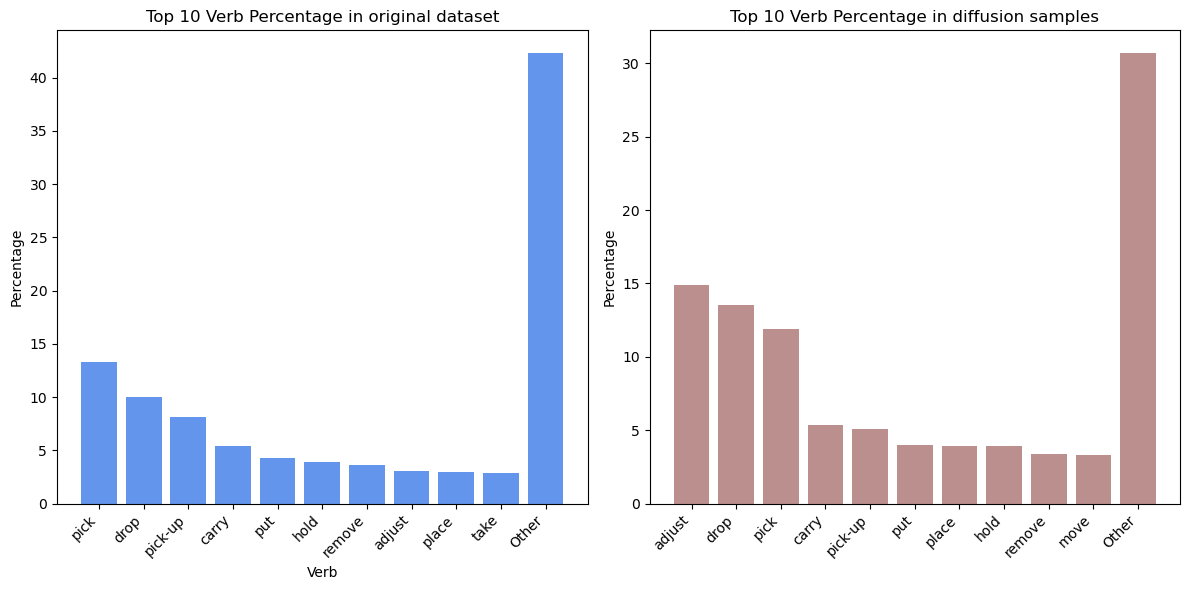

In [27]:
compare_statistics(verbs_list_original, verbs_list_vae, verbs, 'original dataset', 'diffusion samples', 'Verb', other=True)

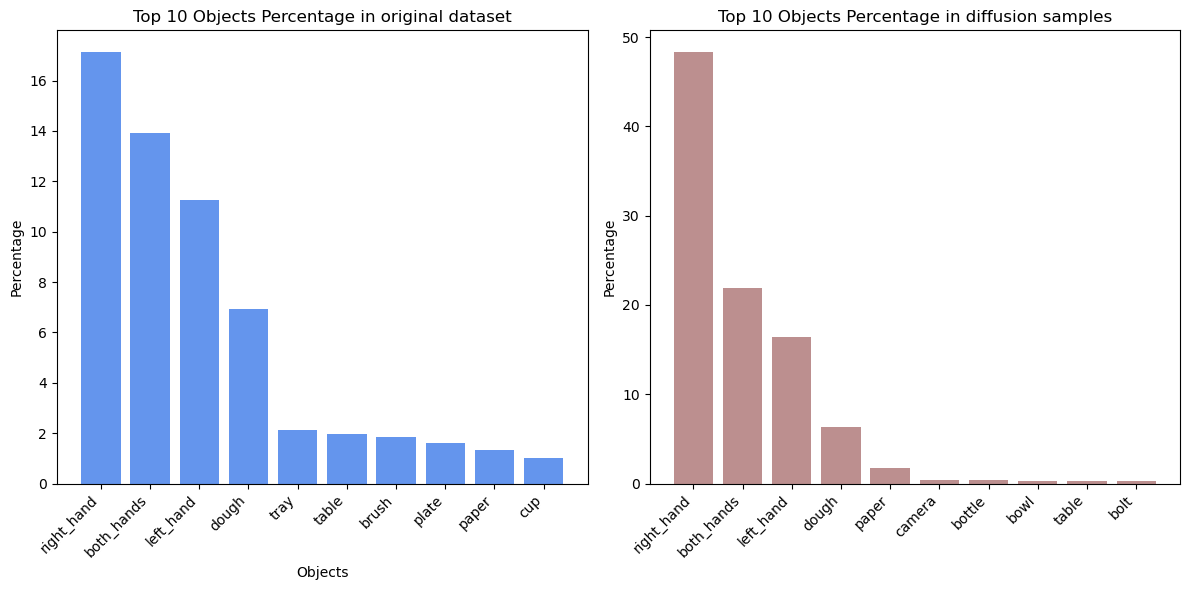

In [28]:
objs_list_original = [triplet[1].item() for triplets in triplets_original for triplet in triplets]
objs_list_vae = [triplet[1].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics(objs_list_original, objs_list_vae, objs, 'original dataset', 'diffusion samples', 'Objects', other=False)

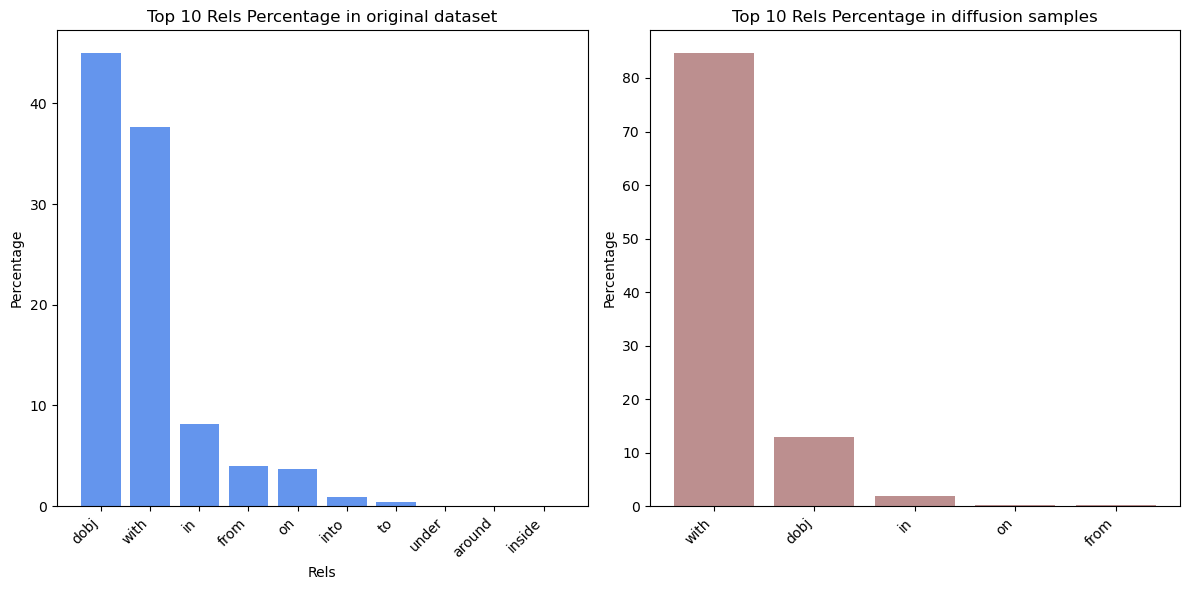

In [29]:
rels_list_original = [triplet[2].item() for triplets in triplets_original for triplet in triplets]
rels_list_diffusion = [triplet[2].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics(rels_list_original, rels_list_diffusion, rels, 'original dataset', 'diffusion samples', 'Rels', other=False)

# t-SNE

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# VAE 1: separate=False, eps=0.1
model_path_vae = 'experiments/best_VAE1000_sep=True_od=256_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_eps=0.1_1719244127/checkpoints/last.ckpt'
vae = load_model('vae', model_path_vae, separate=True)
vae = vae.to(device)
verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


In [20]:
# Step 1: Obtain Latent Representations from the VAE
vae.eval()  # Set VAE to evaluation mode
latent_vectors = []
verb_labels = []
object_labels = []
relationship_labels = []

with torch.no_grad():
    for data in train_loader:
        batch, v_gt, rel_gt = data
        objs = (rel_gt == 1).nonzero(as_tuple=False)
        objects = objs[objs[:, 2] != 13][:,1]
        # rels = objs[objs[:, 2]][:, 2]
        rels = objs[objs[:, 2] != 13][:, 2]
        batch = batch.to(device)
        z = vae.encode(batch)
        latent_vectors.append(z.cpu().numpy())
        verb_labels.append(v_gt.cpu().numpy())
        object_labels.extend([el.cpu().numpy().item() for el in objects])
        relationship_labels.extend([el.cpu().numpy().item() for el in rels])

# Concatenate all latent vectors and labels into single arrays
latent_vectors = np.concatenate(latent_vectors, axis=0)
verb_labels = np.concatenate(verb_labels, axis=0)

# Step 2: Apply t-SNE to the Latent Vectors
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors)

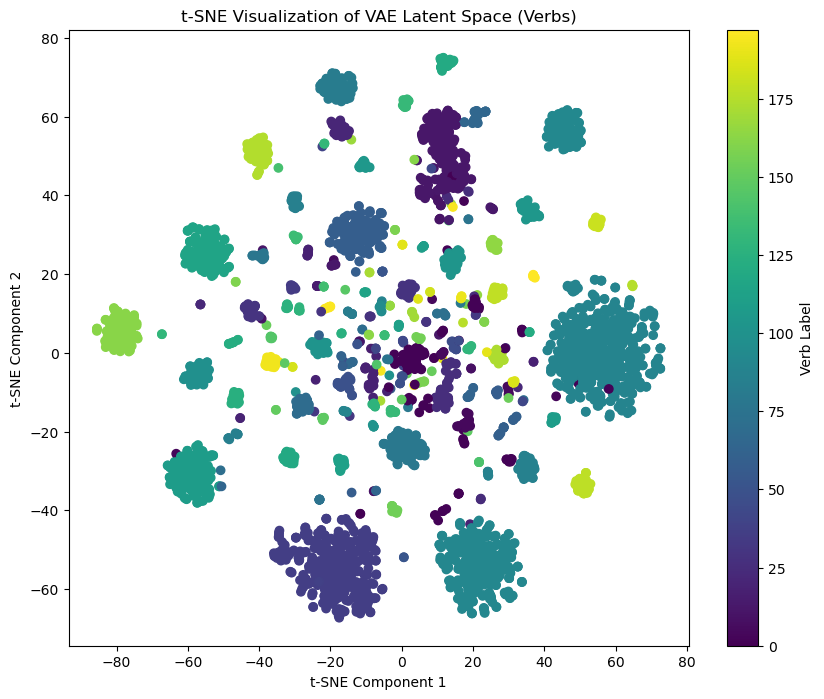

In [21]:
# Plot the t-SNE Visualization with verb labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=verb_labels, cmap='viridis')
plt.colorbar(scatter, label='Verb Label')
plt.title("t-SNE Visualization of VAE Latent Space (Verbs)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

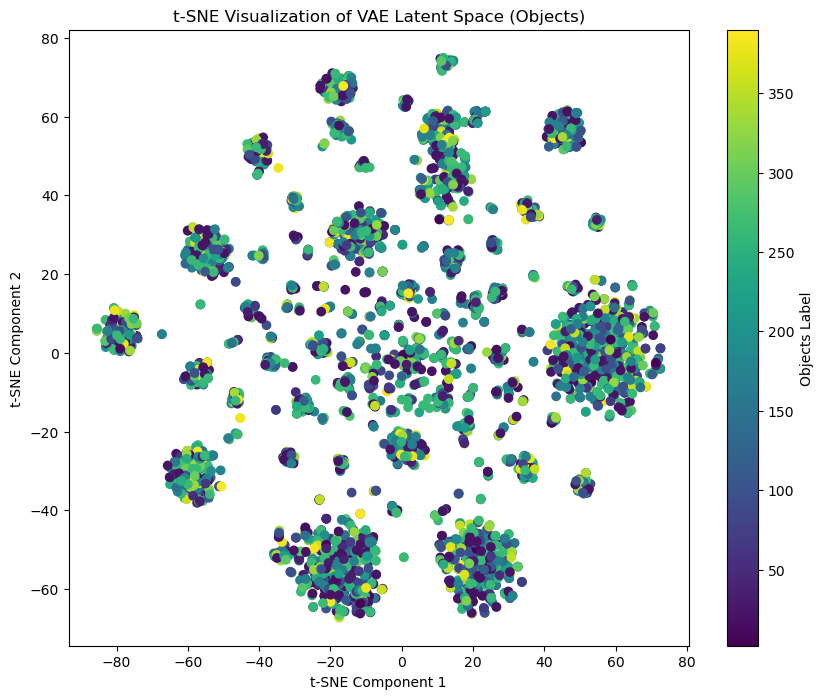

In [22]:
# Plot the t-SNE Visualization with object labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=object_labels[:len(train_dataset)], cmap='viridis')
plt.colorbar(scatter, label='Objects Label')
plt.title("t-SNE Visualization of VAE Latent Space (Objects)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

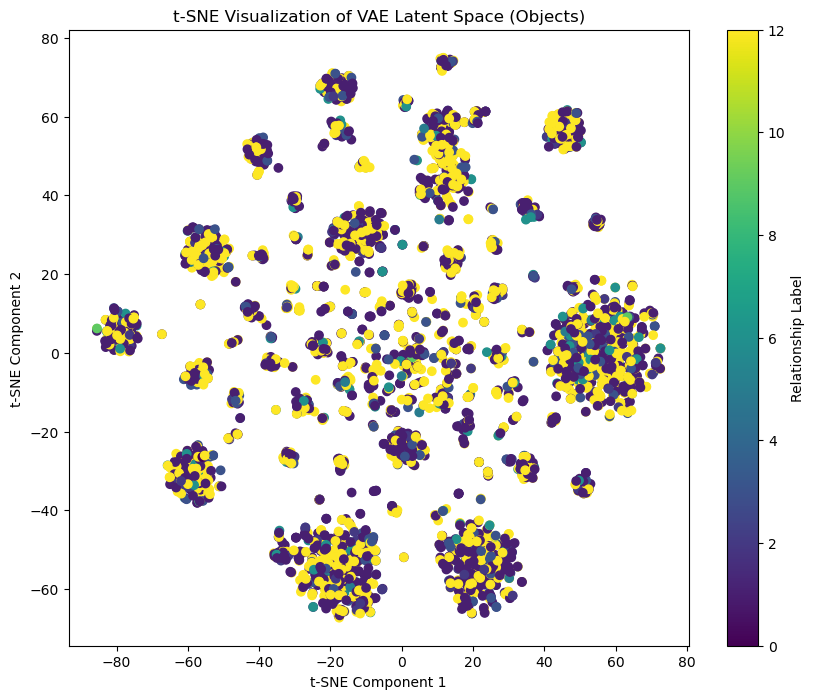

In [23]:
# Plot the t-SNE Visualization with relationship labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=relationship_labels[:len(train_dataset)], cmap='viridis')
plt.colorbar(scatter, label='Relationship Label')
plt.title("t-SNE Visualization of VAE Latent Space (Objects)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()